# 02 Pseudobulk Cell-Type Similarity

Compute cell-type-specific pseudobulk expression similarity between Control, LD, and NMDA.

This notebook keeps conditions separate and compares within each retinal cell type.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sc.settings.verbosity = 2

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "config" / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from fidelity_utils import (
    ensure_output_dirs,
    finite_similarity,
    get_expression_source,
    load_config,
    mean_expression_by_mask,
    normalize_labels,
    resolve_metadata_columns,
    retinal_cell_type_mask,
)

print("Repo root:", REPO_ROOT)
print("scanpy", sc.__version__)
print("anndata", ad.__version__)

Repo root: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis
scanpy 1.9.3
anndata 0.8.0


## Load Data

In [2]:
config = load_config(REPO_ROOT / "config" / "config.yaml")
tables_dir, figures_dir = ensure_output_dirs(config)

h5ad_path = Path(config["data"]["h5ad_path"])
if not h5ad_path.is_absolute():
    h5ad_path = REPO_ROOT / h5ad_path

adata = sc.read_h5ad(h5ad_path)
condition_column, cell_type_column = resolve_metadata_columns(adata, config)
expression, var_names, expression_source = get_expression_source(adata, config)

print(adata)
print("condition_column:", condition_column)
print("cell_type_column:", cell_type_column)
print("expression_source:", expression_source)

AnnData object with n_obs × n_vars = 160875 × 24597
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'renamed_samples', 'predicted_doublets', 'leiden', 'celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'renamed_samples_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
condition_column: renamed_samples
cell_type_column: celltype
expression_source: raw.X


In [3]:
obs = adata.obs.copy()
obs["_condition"] = normalize_labels(obs[condition_column])
obs["_cell_type"] = normalize_labels(obs[cell_type_column])

condition_order = config["metadata"].get("condition_order", ["Control", "LD", "NMDA"])
metrics = config["analysis"].get("similarity_metrics", ["pearson", "spearman", "cosine"])
min_cells = int(config["analysis"].get("min_cells_per_group", 30))
gene_cfg = config["analysis"].get("gene_sets", {})
hvg_ns = gene_cfg.get("hvg_n_top_genes", [500, 1000, 2000])
hvg_flavor = gene_cfg.get("hvg_flavor", "seurat")
min_mean_expression = float(gene_cfg.get("min_mean_expression", 0.0))

retinal_mask = retinal_cell_type_mask(obs, "_cell_type", config)
cell_types = sorted(obs.loc[retinal_mask, "_cell_type"].dropna().unique())
cell_types

['AC', 'BC', 'Cones', 'HC', 'MG', 'MGPC', 'PR precursors', 'RGC', 'Rod']

## Helper Functions

In [4]:
def expressed_gene_mask(matrix, min_mean_expression=0.0):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
    else:
        means = np.asarray(matrix).mean(axis=0).ravel()
    return means > min_mean_expression


def top_variable_gene_indices(matrix, n_top):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
        means_sq = np.asarray(matrix.power(2).mean(axis=0)).ravel()
        variances = means_sq - np.square(means)
    else:
        variances = np.asarray(matrix).var(axis=0)
    n = min(int(n_top), matrix.shape[1])
    return np.argsort(variances)[-n:]


def scanpy_hvg_gene_indices(matrix, n_top, flavor="seurat"):
    n = min(int(n_top), matrix.shape[1])
    if n <= 0:
        return np.array([], dtype=int)
    try:
        hvg_adata = ad.AnnData(X=matrix.copy())
        sc.pp.highly_variable_genes(hvg_adata, n_top_genes=n, flavor=flavor, inplace=True)
        indices = np.where(hvg_adata.var["highly_variable"].to_numpy())[0]
        if indices.size > 0:
            return indices[:n]
    except Exception as exc:
        print(f"Scanpy HVG failed for n_top={n_top}; using variance fallback: {exc}")
    return top_variable_gene_indices(matrix, n)


def condition_pairs(condition_order):
    return [(a, b) for i, a in enumerate(condition_order) for b in condition_order[i + 1:]]

## Compute Similarity Scores

In [5]:
records = []
group_records = []

for cell_type in cell_types:
    cell_mask = (obs["_cell_type"] == cell_type).to_numpy()
    condition_counts = obs.loc[cell_mask, "_condition"].value_counts().reindex(condition_order, fill_value=0)
    present_conditions = [condition for condition in condition_order if condition_counts[condition] > 0]
    if len(present_conditions) < 2:
        continue

    cell_expression = expression[cell_mask]
    expressed_idx = np.where(expressed_gene_mask(cell_expression, min_mean_expression))[0]
    if expressed_idx.size < 2:
        continue

    gene_sets = {"shared_expressed": expressed_idx}
    for n_top in hvg_ns:
        local_idx = scanpy_hvg_gene_indices(cell_expression[:, expressed_idx], n_top, hvg_flavor)
        gene_sets[f"hvg_{int(n_top)}"] = expressed_idx[local_idx]

    centroids = {}
    for condition in present_conditions:
        group_mask = cell_mask & (obs["_condition"] == condition).to_numpy()
        centroids[condition] = mean_expression_by_mask(expression, group_mask)
        group_records.append({"cell_type": cell_type, "condition": condition, "n_cells": int(group_mask.sum())})

    for gene_set, gene_idx in gene_sets.items():
        for left, right in condition_pairs(condition_order):
            if left not in centroids or right not in centroids:
                continue
            for metric in metrics:
                score = finite_similarity(centroids[left][gene_idx], centroids[right][gene_idx], metric)
                records.append(
                    {
                        "cell_type": cell_type,
                        "comparison": f"{left}_vs_{right}",
                        "condition_a": left,
                        "condition_b": right,
                        "metric": metric,
                        "gene_set": gene_set,
                        "n_genes": int(gene_idx.size),
                        "similarity": score,
                        "n_cells_a": int(condition_counts[left]),
                        "n_cells_b": int(condition_counts[right]),
                        "low_cell_count_warning": bool(condition_counts[left] < min_cells or condition_counts[right] < min_cells),
                        "expression_source": expression_source,
                    }
                )

similarity = pd.DataFrame(records)
group_meta = pd.DataFrame(group_records)

similarity.to_csv(tables_dir / "pseudobulk_similarity_scores.csv", index=False)
group_meta.to_csv(tables_dir / "pseudobulk_group_metadata.csv", index=False)
similarity.head()

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, a

,cell_type,comparison,condition_a,condition_b,metric,gene_set,n_genes,similarity,n_cells_a,n_cells_b,low_cell_count_warning,expression_source
0,AC,Control_vs_LD,Control,LD,pearson,shared_expressed,24184,0.905019,13751,342,False,raw.X
1,AC,Control_vs_LD,Control,LD,spearman,shared_expressed,24184,0.914735,13751,342,False,raw.X
2,AC,Control_vs_LD,Control,LD,cosine,shared_expressed,24184,0.924181,13751,342,False,raw.X
3,AC,Control_vs_NMDA,Control,NMDA,pearson,shared_expressed,24184,0.905000,13751,1424,False,raw.X
4,AC,Control_vs_NMDA,Control,NMDA,spearman,shared_expressed,24184,0.924387,13751,1424,False,raw.X


In [6]:
group_meta.pivot_table(index="cell_type", columns="condition", values="n_cells", fill_value=0, observed=False)

condition,Control,LD,NMDA
cell_type,,,
AC,13751,342,1424
BC,62885,545,848
Cones,10127,372,424
HC,17989,692,1070
MG,8707,4835,4611
MGPC,1515,1743,2273
PR precursors,1175,1619,2140
RGC,4299,157,456
Rod,6384,886,2120


## Main Heatmaps

In [18]:
METRIC = "spearman"
GENE_SET = "hvg_2000"

plot_table = similarity[(similarity["metric"] == METRIC) & (similarity["gene_set"] == GENE_SET)]
heat = plot_table.pivot_table(index="cell_type", columns="comparison", values="similarity", observed=False)
heat

comparison,Control_vs_LD,Control_vs_NMDA,LD_vs_NMDA
cell_type,,,
AC,0.824305,0.830591,0.930467
BC,0.826474,0.842245,0.945312
Cones,0.768422,0.811742,0.884829
HC,0.805860,0.800102,0.923606
MG,0.792772,0.790905,0.958425
MGPC,0.808531,0.833905,0.947086
PR precursors,0.808762,0.836734,0.935127
RGC,0.781435,0.811539,0.921956
Rod,0.750421,0.744379,0.941289


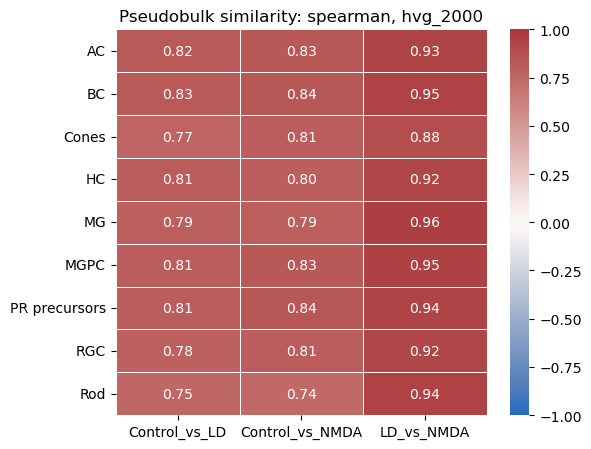

In [19]:
fig, ax = plt.subplots(figsize=(6, max(3, 0.4 * heat.shape[0] + 1)))
sns.heatmap(heat, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Pseudobulk similarity: {METRIC}, {GENE_SET}")
fig.tight_layout()
fig.savefig(figures_dir / f"pseudobulk_similarity_{METRIC}_{GENE_SET}.png", dpi=300, bbox_inches="tight")

## Compare Metrics And Gene Sets

In [9]:
summary = similarity.pivot_table(
    index=["cell_type", "comparison"],
    columns=["metric", "gene_set"],
    values="similarity",
    observed=False,
)
summary.to_csv(tables_dir / "pseudobulk_similarity_metric_gene_set_summary.csv")
summary

metric                           cosine                                       \
gene_set                       hvg_1000  hvg_2000   hvg_500 shared_expressed   
cell_type     comparison                                                       
AC            Control_vs_LD    0.774005  0.780315  0.778539         0.924181   
              Control_vs_NMDA  0.787961  0.795210  0.767739         0.923412   
              LD_vs_NMDA       0.914658  0.946634  0.888803         0.977273   
BC            Control_vs_LD    0.766159  0.777870  0.814931         0.894752   
              Control_vs_NMDA  0.778012  0.796222  0.801859         0.911667   
              LD_vs_NMDA       0.952362  0.958282  0.938430         0.971279   
Cones         Control_vs_LD    0.496462  0.577109  0.475015         0.820483   
              Control_vs_NMDA  0.560111  0.630670  0.546276         0.857518   
              LD_vs_NMDA       0.974268  0.972849  0.965559         0.982145   
HC            Control_vs_LD    0.548998  0.616784  0.447366         0.897817   
              Control_vs_NMDA  0.545382  0.614708  0.474740         0.901595   
              LD_vs_NMDA       0.958103  0.963576  0.951055         0.981800   
MG            Control_vs_LD    0.494856  0.596335  0.487340         0.901592   
              Control_vs_NMDA  0.513266  0.616322  0.496536         0.911003   
              LD_vs_NMDA       0.910273  0.948185  0.867248         0.982546   
MGPC          Control_vs_LD    0.661205  0.673012  0.689047         0.887727   
              Control_vs_NMDA  0.746705  0.757092  0.757007         0.904907   
              LD_vs_NMDA       0.973645  0.975115  0.974440         0.989460   
PR precursors Control_vs_LD    0.626326  0.681942  0.592647         0.903522   
              Control_vs_NMDA  0.699005  0.740958  0.675546         0.910835   
              LD_vs_NMDA       0.972247  0.974755  0.974863         0.989708   
RGC           Control_vs_LD    0.677955  0.765671  0.577297         0.911447   
              Control_vs_NMDA  0.691021  0.777752  0.563150         0.915155   
              LD_vs_NMDA       0.930457  0.957546  0.899663         0.988232   
Rod           Control_vs_LD    0.517929  0.592341  0.414778         0.820684   
              Control_vs_NMDA  0.499994  0.496916  0.347430         0.740605   
              LD_vs_NMDA       0.874636  0.868782  0.830500         0.927701   

metric                          pearson                                       \
gene_set                       hvg_1000  hvg_2000   hvg_500 shared_expressed   
cell_type     comparison                                                       
AC            Control_vs_LD    0.680707  0.716482  0.668264         0.905019   
              Control_vs_NMDA  0.697680  0.733327  0.640274         0.905000   
              LD_vs_NMDA       0.879896  0.931667  0.838522         0.971927   
BC            Control_vs_LD    0.716051  0.741586  0.766413         0.878059   
              Control_vs_NMDA  0.718304  0.755700  0.729066         0.897084   
              LD_vs_NMDA       0.944175  0.952854  0.924845         0.966692   
Cones         Control_vs_LD    0.450205  0.541231  0.425510         0.798326   
              Control_vs_NMDA  0.509753  0.594068  0.487036         0.840221   
              LD_vs_NMDA       0.973184  0.971305  0.964419         0.980173   
HC            Control_vs_LD    0.490989  0.571630  0.383795         0.880178   
              Control_vs_NMDA  0.474175  0.562078  0.386891         0.885193   
              LD_vs_NMDA       0.954544  0.960413  0.948886         0.978844   
MG            Control_vs_LD    0.421620  0.550028  0.403897         0.884863   
              Control_vs_NMDA  0.434725  0.565215  0.406291         0.896814   
              LD_vs_NMDA       0.901321  0.943810  0.852429         0.979849   
MGPC          Control_vs_LD    0.643196  0.654057  0.667752         0.868709   
              Control_vs_NMDA  0.715812  0.729494  0.721472         0.890401   

In [10]:
warnings = similarity[similarity["low_cell_count_warning"]].sort_values(["cell_type", "comparison", "metric", "gene_set"])
warnings.to_csv(tables_dir / "pseudobulk_low_cell_count_warnings.csv", index=False)
warnings[["cell_type", "comparison", "metric", "gene_set", "n_cells_a", "n_cells_b", "similarity"]].head(50)

,cell_type,comparison,metric,gene_set,n_cells_a,n_cells_b,similarity


## Script Equivalent

After reviewing the notebook results, the equivalent command is:

```bash
python scripts/pseudobulk_similarity.py --config config/config.yaml
```